# Exploring Basic Neural Network Architectures and Hyperparameter Tuning

In this notebook, I explore foundational neural network architectures for regression tasks using the California Housing dataset. My primary focus is on understanding how different model-building approaches in Keras—ranging from rigid to flexible frameworks—shape both the development workflow and the resulting model performance.

**What I cover here:**
- **MLP construction** using both the Sequential and Functional APIs, comparing their trade-offs in terms of flexibility and self-containment
- **The impact of feature scaling** on training dynamics, convergence speed, and final accuracy
- **Callback mechanisms** such as early stopping and checkpoint saving for automating training decisions
- **Transitioning from external preprocessing to integrated normalization layers** to build deployment-ready models
- **Wide & Deep architectures** with different input routing strategies and auxiliary outputs for regularisation

This notebook serves as my hands-on reference for understanding how architectural and API choices shape the model development lifecycle, before I move on to more specialised network designs.

In [1]:
# -- Basic libraries --
from pathlib import Path
from time import strftime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -- ML framework --
import sklearn.model_selection
import sklearn.metrics
import sklearn.preprocessing
import sklearn.pipeline

# -- ANN framework --
import tensorflow as tf

# 1. Feed-Forward Neural Networks: MLP and Wide & Deep

For this section, I work with the California Housing dataset—a classic regression benchmark where the goal is to predict median house values based on features like location, income levels, and housing characteristics. The dataset's moderate size and continuous features make it well-suited for experimenting with different neural network configurations without excessive training times.

My progression through this section follows a deliberate path: I start with the simplest possible setup to expose common pitfalls, then incrementally introduce improvements—standardization, architectural flexibility, and training automation—so each enhancement's impact is clearly measurable against the previous baseline.

In [2]:
# Importing the housing dataset
housing = tf.keras.datasets.california_housing.load_data()
(x_train, y_train), (x_test, y_test) = housing

In [3]:
# Getting to know the data
print(
    "-- Train data info: --",
    x_train.dtype,
    x_train.shape,
    x_train[:5],
    "\n",
    "-- Test data info: --",
    x_test.dtype,
    x_test.shape,
    x_test[:5],
    sep= "\n"
)

-- Train data info: --
float32
(16512, 8)
[[-1.18270e+02  3.40900e+01  5.20000e+01  2.32700e+03  5.55000e+02
   1.04800e+03  4.91000e+02  3.78470e+00]
 [-1.18360e+02  3.39600e+01  2.10000e+01  1.80200e+03  5.56000e+02
   1.28600e+03  5.57000e+02  2.72840e+00]
 [-1.22390e+02  3.77600e+01  5.20000e+01  1.87700e+03  4.27000e+02
   7.12000e+02  3.98000e+02  3.97220e+00]
 [-1.17950e+02  3.39200e+01  1.10000e+01  3.12700e+03  7.06000e+02
   1.59400e+03  6.94000e+02  4.34260e+00]
 [-1.22520e+02  3.79200e+01  2.40000e+01  4.21000e+02  6.40000e+01
   1.63000e+02  7.50000e+01  1.45833e+01]]


-- Test data info: --
float32
(4128, 8)
[[-1.1836e+02  3.4080e+01  4.5000e+01  2.1950e+03  4.8300e+02  1.2650e+03
   4.5500e+02  3.3864e+00]
 [-1.2020e+02  3.4630e+01  1.4000e+01  2.6470e+03  5.1500e+02  1.4870e+03
   4.8800e+02  4.4519e+00]
 [-1.2121e+02  3.7810e+01  8.0000e+00  1.8830e+03  2.9800e+02  9.9900e+02
   3.0100e+02  5.1930e+00]
 [-1.2206e+02  3.7850e+01  1.7000e+01  7.4750e+03  1.5560e+03  2.09

In [4]:
# Subdividing the training set into training and validation via a conservative 80-20 split
# For features
x_tra = x_train[:-int(len(x_train) * 0.2), :]
x_val = x_train[-int(len(x_train) * 0.2):, :]

# For targets
y_tra = y_train[:-int(len(y_train) * 0.2)]
y_val = y_train[-int(len(y_train) * 0.2):]

From this initial exploration, I note that the data arrives pre-split into training and test sets, which I use as-is. All 8 features are continuous—the preloaded version strips out the categorical ocean proximity feature present in the original dataset. This simplifies preprocessing but means I am working with a reduced feature space compared to what I explored in my earlier scikit-learn projects with the same data.

## 1.1. Constructing a MLP

I begin with the most straightforward architecture—a Multi-Layer Perceptron. My goal here is twofold: first, to establish a performance baseline for this dataset under a neural network approach; and second, to compare two implementation strategies—the Sequential API (concise but rigid) versus the Functional API (more verbose but capable of embedding preprocessing and supporting complex topologies). This comparison reveals practical trade-offs that inform how I structure models going forward.

### Sequential API

**Unstandardized features model**

I intentionally start without feature scaling to demonstrate its impact on training. This "naive" approach establishes a baseline that highlights why preprocessing matters for neural network convergence.

In [5]:
# Building a baseline MLP without standardization to expose the effect of unscaled features
tf.random.set_seed(15) # For guaranteeing reproducibility
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[8,]),
    tf.keras.layers.Dense(100, activation="relu"), # Hidden 1
    tf.keras.layers.Dense(50, activation="relu"), # Hidden 2
    tf.keras.layers.Dense(10, activation="relu"), # Hidden 3
    tf.keras.layers.Dense(1) # Output layer without activation function as it is an unconstrained regression task
])

# Using MSE as the loss function, which is natural for regression tasks
mlp_model.compile(loss="mean_squared_error", optimizer="adam", metrics=["root_mean_squared_error"])

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,471 (25.28 KB)

 Trainable params: 6,471 (25.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Keeping epochs low intentionally—without standardization, extended training would waste resources
history = mlp_model.fit(x=x_tra, y=y_tra, validation_data=(x_val, y_val), epochs=10)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 31714023424.0000 - root_mean_squared_error: 178084.3125 - val_loss: 25759576064.0000 - val_root_mean_squared_error: 160497.9062
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20696692736.0000 - root_mean_squared_error: 143863.4531 - val_loss: 15785663488.0000 - val_root_mean_squared_error: 125641.0078
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12247304192.0000 - root_mean_squared_error: 110667.5391 - val_loss: 11114613760.0000 - val_root_mean_squared_error: 105425.8672
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10976104448.0000 - root_mean_squared_error: 104766.9062 - val_loss: 10723132416.0000 - val_root_mean_squared_error: 103552.5625
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10671255552.0000 - root_mean_squared_error: 103301.7656 - val_loss: 10383060992.0000 - val_root_mean_squared_error: 101897.3047
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 

In [7]:
np.max(history.history["loss"])

np.float64(31714023424.0)

The results confirm my expectation: without proper scaling, the RMSE values are extremely high on both training and validation sets. The gradient descent algorithm struggles with features on vastly different scales, causing erratic updates and poor convergence. This motivates the next step—applying standardization to bring all features to a common scale.

**Standardized features model**

Now I apply StandardScaler to normalize the features before training. Note that I fit the scaler only on training data to avoid data leakage—a subtle but important detail for valid model evaluation.

In [ ]:
# Fitting the scaler only on training data to prevent data leakage
scaler = sklearn.preprocessing.StandardScaler()
scaler = scaler.fit(x_tra)

# Applying the learned transformation to both splits
std_x_tra = scaler.transform(x_tra)
std_x_val = scaler.transform(x_val)

print(
    std_x_tra[:5],
    std_x_val[:5],
    sep="\n\n"
)

[[ 0.6482476  -0.72322077  1.85232    -0.14237864  0.03717742 -0.33747274
  -0.02615596 -0.04231662]
 [ 0.603281   -0.784224   -0.6160778  -0.38027763  0.03953395 -0.1274346
   0.14472945 -0.6001574 ]
 [-1.4101332   0.9989319   1.85232    -0.34629208 -0.2644579  -0.63399714
  -0.26694903  0.05670369]
 [ 0.80812156 -0.8029945  -1.4123352   0.22013412  0.39301285  0.14437945
   0.49944615  0.25231498]
 [-1.4750808   1.074012   -0.37720057 -1.0060652  -1.1198769  -1.1184969
  -1.1032519   5.660514  ]]

[[ 1.297734   -0.8827664  -0.53645205  0.49790955  1.0033531   0.51238745
   0.8360386  -1.3524476 ]
 [-0.45088938 -0.46513274 -1.6512123  -0.07214179  0.11022973 -0.00300024
   0.10071351 -0.41922742]
 [-1.4501028   1.2476364  -1.1734579   0.4942844   0.7229265  -0.13537721
   0.70916915 -0.6860278 ]
 [ 0.6882132  -0.71383554 -0.2179491  -0.45459276 -0.19376214 -0.24304383
  -0.1659713  -0.23349181]
 [-1.3401886   1.1678628   1.4541913  -0.5900819  -0.5684498  -0.5616311
  -0.5569364  -0.6

In [ ]:
# Rebuilding from scratch—the previous model's weights are corrupted by the unscaled training
tf.random.set_seed(15) #For guaranteeing reproducibility
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[8,]),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

mlp_model.compile(loss="mean_squared_error", optimizer="adam", metrics=["root_mean_squared_error"])

In [ ]:
# Training on the standardized data—same architecture, same epochs, only the input scale changes
history = mlp_model.fit(x = std_x_tra, y = y_tra, validation_data=(std_x_val, y_val), epochs=10)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 54442164224.0000 - root_mean_squared_error: 233328.4531 - val_loss: 49085632512.0000 - val_root_mean_squared_error: 221552.7812
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 29485244416.0000 - root_mean_squared_error: 171712.6875 - val_loss: 14195510272.0000 - val_root_mean_squared_error: 119144.9141
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 11486637056.0000 - root_mean_squared_error: 107175.7266 - val_loss: 9845154816.0000 - val_root_mean_squared_error: 99222.7500
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9271203840.0000 - root_mean_squared_error: 96287.0938 - val_loss: 8205009408.0000 - val_root_mean_squared_error: 90581.5078
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7979628544.0000 - root_mean_squared_error: 89328.7656 - val_loss: 7113521152.0000 - val_root_mean_squared_error: 84341.6953
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7042164736

**Key takeaway:** Standardization alone yields approximately a 25% reduction in training RMSE and 26% in validation RMSE. This improvement stems from gradient descent converging more efficiently when features share similar scales—the optimizer can take more consistent steps across all dimensions, avoiding the oscillating updates that dominated the unscaled run.

However, this external preprocessing approach introduces a practical burden: the scaler object must be serialized and managed alongside the model, and I must remember to apply the exact same transformation at inference time. Any mismatch—a forgotten transform, a differently fitted scaler—would silently degrade predictions. This overhead is what motivates my transition to the Functional API next, where I can embed normalization directly into the model graph and produce a single self-contained artefact.

### Functional API

The Functional API offers the flexibility to include preprocessing layers directly within the model graph. By integrating a Normalization layer, I create a self-contained model that handles both scaling and prediction in a single forward pass—eliminating the need to manage a separate scaler object and reducing the risk of preprocessing mismatches between training and inference.

This also sets the groundwork for the architectures I build later in this notebook, since the Functional API is the only way to construct models with multiple inputs, multiple outputs, or non-sequential layer connections.

In [ ]:
# Building the MLP with the Functional API—normalization is now part of the graph
tf.random.set_seed(15) #For guaranteeing reproducibility

# The Normalization layer will learn mean/variance when I call adapt() below
normalizer = tf.keras.layers.Normalization()

input_ = tf.keras.layers.Input(shape=[8,])
normalized = normalizer(input_)
hidden_1 = tf.keras.layers.Dense(100, activation="relu")(normalized)
hidden_2 = tf.keras.layers.Dense(50, activation="relu")(hidden_1)
hidden_3 = tf.keras.layers.Dense(10, activation="relu")(hidden_2)
output_ = tf.keras.layers.Dense(1)(hidden_3)

# Materialising the model
mlp_model = tf.keras.Model(inputs = [input_], outputs = [output_])

mlp_model.compile(loss="mean_squared_error", optimizer="adam", metrics=["root_mean_squared_error"])

# Adapting the normalizer on training data only
normalizer.adapt(x_tra)

mlp_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,488 (25.35 KB)

 Trainable params: 6,471 (25.28 KB)

 Non-trainable params: 17 (72.00 B)

With normalization now embedded in the architecture, I can train for longer periods and leverage Keras callbacks to automate training decisions. I implement two callbacks:
- **ModelCheckpoint**: Saves model weights after each epoch, providing recovery points if training is interrupted or if I want to resume from a specific state later
- **EarlyStopping**: Monitors validation performance and halts training when improvement stalls for 10 consecutive epochs, automatically restoring the best weights encountered during training

Together, these prevent wasted computation on overfitting epochs while ensuring I never lose the best model state—an essential pattern for any non-trivial training run.

In [12]:
# Establishing the callback functionalities
checkpoints_log = tf.keras.callbacks.ModelCheckpoint("mlp_checkpoints.weights.h5", save_weights_only=True)
early_stopping_mlp = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# Fitting the model
history = mlp_model.fit(x=x_tra, y=y_tra, validation_data=(x_val, y_val), epochs= 100, callbacks=[checkpoints_log, early_stopping_mlp])

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 53927841792.0000 - root_mean_squared_error: 232223.6875 - val_loss: 46718468096.0000 - val_root_mean_squared_error: 216144.5469
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25994379264.0000 - root_mean_squared_error: 161227.7188 - val_loss: 12822842368.0000 - val_root_mean_squared_error: 113237.9922
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10934372352.0000 - root_mean_squared_error: 104567.5469 - val_loss: 9420148736.0000 - val_root_mean_squared_error: 97057.4531
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8889006080.0000 - root_mean_squared_error: 94281.5234 - val_loss: 7836632576.0000 - val_root_mean_squared_error: 88524.7578
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7628781568.0000 - root_mean_squared_error: 87342.8984 - val_loss: 6780427776.0000 - val_root_mean_squared_error: 82343.3516
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6701

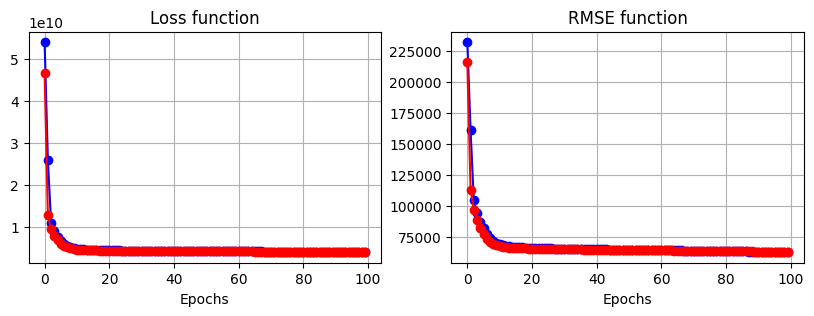

In [ ]:
# Visualizing the evolution of the training
evolution = history.history

fig, (ax1, ax2) = plt.subplots(ncols= 2, figsize= (10, 3))
ax1.plot(history.epoch, evolution["loss"], "-ob", label="Training loss")
ax1.plot(history.epoch, evolution["val_loss"], "-or", label="Validation loss")
ax1.set_xlabel("Epochs")
ax1.set_title("Loss function")
ax1.grid()

ax2.plot(history.epoch, evolution["root_mean_squared_error"], "-ob", label="Training RMSE")
ax2.plot(history.epoch, evolution["val_root_mean_squared_error"], "-or", label="Validation RMSE")
ax2.set_xlabel("Epochs")
ax2.set_title("RMSE function")
ax2.grid()

plt.show()

From the loss and RMSE curves I can observe that, despite training for one hundred epochs, the model has not fully converged—the loss function is still decreasing when early stopping triggers. This tells me the default learning rate is resulting in a slow learning curve, making the gradient descent process significantly slower than necessary.

This is a clear illustration of one of the pitfalls of relying solely on default hyperparameters: while the model is learning, it is doing so inefficiently. The next logical step in my workflow would be hyperparameter tuning—adjusting the learning rate, experimenting with different optimizers, or modifying the architecture—but for this notebook my priority is comparing architectural patterns rather than squeezing optimal performance from a single configuration.

## 1.2. Wide & Deep Feed-Forward ANN

I now move to a more sophisticated architecture: the Wide & Deep model. The core idea is that by providing a shortcut connection from the input directly to the output layer (the "wide" path), the model can simultaneously learn high-level abstract patterns through its hidden layers (the "deep" path) and preserve direct access to raw feature signals. This dual pathway can be especially powerful when some features have strong linear relationships with the target that the deep path might distort through excessive non-linear transformation.

My goal here is not to achieve state-of-the-art results but to assess whether this architectural change alone—without additional hyperparameter tuning—yields measurable improvements over the baseline MLP. I test three variants:
1. **Full-feature wide connection** — all features feed both the deep and wide paths
2. **Split-feature routing** — a subset of features goes deep while the rest go wide
3. **Auxiliary output for regularisation** — an additional output from the deep path to constrain its learned representations

### Wide & Deep with direct connection to the input layer and for all the features

In [ ]:
# Wide & Deep: all features feed both the deep path (hidden layers) and the wide path (skip connection)
tf.random.set_seed(15) #For guaranteeing reproducibility
normalizer = tf.keras.layers.Normalization()
concatenate = tf.keras.layers.Concatenate()

# Deep path
input_ = tf.keras.layers.Input(shape=[8,])
normalized = normalizer(input_)
hidden_1 = tf.keras.layers.Dense(100, activation="relu")(normalized)
hidden_2 = tf.keras.layers.Dense(50, activation="relu")(hidden_1)
hidden_3 = tf.keras.layers.Dense(10, activation="relu")(hidden_2)

# Merging the deep output with the normalized input (wide path) before the final prediction
concatenation = concatenate([hidden_3, normalized])
output_ = tf.keras.layers.Dense(1)(concatenation)

w_d_model = tf.keras.Model(inputs = [input_], outputs = [output_])

w_d_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 8)         │         17 │ input_layer_3[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 100)       │        900 │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 50)        │      5,050 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 10)        │        510 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 18)        │          0 │ dense_14[0][0],   │
│ (Concatenate)       │                   │            │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         19 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,496 (25.38 KB)

 Trainable params: 6,479 (25.31 KB)

 Non-trainable params: 17 (72.00 B)

In [15]:
# Creating the fundamentals for a tensorboard callback
def get_run_logdir(root_logdir = "w_d_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

In [ ]:
# Slightly higher learning rate (0.002 vs default 0.001) to accelerate convergence
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

w_d_model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=["root_mean_squared_error"])

normalizer.adapt(x_tra)

# Adding TensorBoard callback for detailed training profiling alongside checkpoints and early stopping
checkpoints_log = tf.keras.callbacks.ModelCheckpoint(filepath="w_d_checkpoints.weights.h5",
                                                     save_weights_only=True)
early_stopping_w_d = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_wd = tf.keras.callbacks.TensorBoard(get_run_logdir(),
                                                profile_batch = (100, 200))

w_d_history = w_d_model.fit(x = x_tra, y = y_tra, validation_data=(x_val, y_val), epochs=100, callbacks=[checkpoints_log, early_stopping_w_d, tensorboard_wd])

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 42580115456.0000 - root_mean_squared_error: 206349.5000 - val_loss: 13960488960.0000 - val_root_mean_squared_error: 118154.5156
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10145385472.0000 - root_mean_squared_error: 100724.3047 - val_loss: 7997386240.0000 - val_root_mean_squared_error: 89428.1094
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7362679808.0000 - root_mean_squared_error: 85806.0625 - val_loss: 6164785152.0000 - val_root_mean_squared_error: 78516.1484
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5918291968.0000 - root_mean_squared_error: 76930.4375 - val_loss: 5180910080.0000 - val_root_mean_squared_error: 71978.5391
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5157093888.0000 - root_mean_squared_error: 71812.9062 - val_loss: 4725263872.0000 - val_root_mean_squared_error: 68740.5547
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47947089

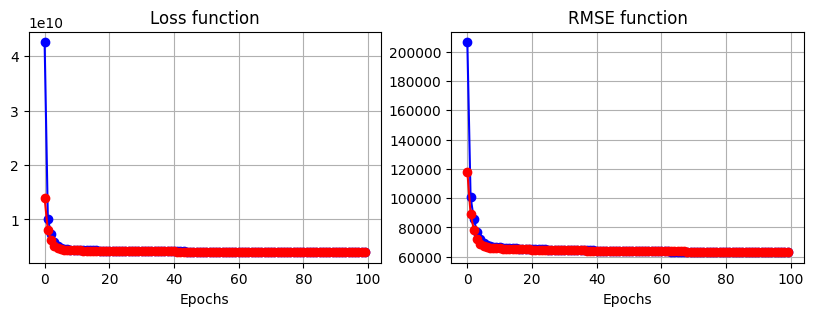

In [ ]:
# Visualizing the evolution of the training
evolution = w_d_history.history

fig, (ax1, ax2) = plt.subplots(ncols= 2, figsize= (10, 3))
ax1.plot(history.epoch, evolution["loss"], "-ob", label="Training loss")
ax1.plot(history.epoch, evolution["val_loss"], "-or", label="Validation loss")
ax1.set_xlabel("Epochs")
ax1.set_title("Loss function")
ax1.grid()

ax2.plot(history.epoch, evolution["root_mean_squared_error"], "-ob", label="Training RMSE")
ax2.plot(history.epoch, evolution["val_root_mean_squared_error"], "-or", label="Validation RMSE")
ax2.set_xlabel("Epochs")
ax2.set_title("RMSE function")
ax2.grid()

plt.show()

From this first Wide & Deep variant, I observe no meaningful improvement over the baseline MLP. In fact, the model slightly underperforms—with an approximate 0.7% increase in training RMSE and around 0.08% in validation RMSE. This suggests that, for this dataset and feature set, the direct wide connection does not contribute additional predictive signal beyond what the deep path already captures. The concatenation of raw features with the deep representations may even introduce mild noise into the final layer.

This result is not surprising: the California Housing features are all continuous and moderately correlated, so the deep path is already well-equipped to learn the relevant relationships. The Wide & Deep pattern tends to shine more when there is a mix of dense and sparse features (e.g., categorical embeddings alongside numerical data), which is not the case here.

### Wide & Deep with partial treatment of some features

In this variant, I test a more deliberate feature-routing strategy: only a subset of features traverses the hidden layers while the remaining features bypass them entirely and connect directly to the output. The hypothesis is that separating features by their expected interaction complexity—sending the more "informative" ones through the deep path and the rest through the wide path—might let each pathway specialise.

For this exercise, I route the first four features (MedInc, HouseAge, AveRooms, AveBedrms) through the deep path and the remaining four (Population, AveOccup, Latitude, Longitude) through the wide path. This split is arbitrary and serves to demonstrate the multi-input pattern rather than a carefully engineered feature selection.

In [ ]:
# Split-feature Wide & Deep: separate inputs for the deep and wide paths
tf.random.set_seed(15) #For guaranteeing reproducibility
normalize1 = tf.keras.layers.Normalization()
normalize2 = tf.keras.layers.Normalization()
concatenate = tf.keras.layers.Concatenate()

# Deep path — first 4 features go through hidden layers
input1__ = tf.keras.layers.Input(shape=[4,])
normalized1 = normalize1(input1__)
hidden_1 = tf.keras.layers.Dense(100, activation="relu")(normalized1)
hidden_2 = tf.keras.layers.Dense(50, activation="relu")(hidden_1)
hidden_3 = tf.keras.layers.Dense(10, activation="relu")(hidden_2)

# Wide path — remaining 4 features connect directly to the output
input2__ = tf.keras.layers.Input(shape=[4,])
normalized2 = normalize2(input2__)

# Merging both paths before prediction
concatenation = concatenate([hidden_3, normalized2])
output__ = tf.keras.layers.Dense(1)(concatenation)

w_d_model_2 = tf.keras.Model(inputs = [input1__, input2__], outputs = [output__])
w_d_model_2.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_8     │ (None, 4)         │          9 │ input_layer_14[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 100)       │        500 │ normalization_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 50)        │      5,050 │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 10)        │        510 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_9     │ (None, 4)         │          9 │ input_layer_15[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 14)        │          0 │ dense_37[0][0],   │
│ (Concatenate)       │                   │            │ normalization_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 1)         │         15 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,093 (23.81 KB)

 Trainable params: 6,075 (23.73 KB)

 Non-trainable params: 18 (80.00 B)

In [31]:
# Compiling the model
w_d_model_2.compile(loss="mean_squared_error", optimizer="adam", metrics=["root_mean_squared_error"])

# Selecting the features for each path
x_tra_deep, x_tra_wide = x_tra[:, :4], x_tra[:, 4:]
x_val_deep, x_val_wide = x_val[:, :4], x_val[:, 4:]

# Adapting the input layers
normalize1.adapt(x_tra_deep)
normalize2.adapt(x_tra_wide)

# Creating the callbacks
checkpoints_log = tf.keras.callbacks.ModelCheckpoint(filepath="wd2_checkpoints.weights.h5",
                                                     save_weights_only=True)
early_stopping_wd2 = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# Fitting the model
wd_history_2 = w_d_model_2.fit([x_tra_deep, x_tra_wide], y_tra, epochs=100,
                               validation_data=([x_val_deep, x_val_wide], y_val),
                               callbacks=[checkpoints_log, early_stopping_wd2])

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 36496834560.0000 - root_mean_squared_error: 191041.4531 - val_loss: 23912738816.0000 - val_root_mean_squared_error: 154637.4375
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 16912698368.0000 - root_mean_squared_error: 130048.8281 - val_loss: 15098253312.0000 - val_root_mean_squared_error: 122874.9531
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 14182595584.0000 - root_mean_squared_error: 119090.7031 - val_loss: 14242322432.0000 - val_root_mean_squared_error: 119341.2031
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13523439616.0000 - root_mean_squared_error: 116290.3281 - val_loss: 13552103424.0000 - val_root_mean_squared_error: 116413.5000
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12889645056.0000 - root_mean_squared_error: 113532.5703 - val_loss: 12874547200.0000 - val_root_mean_squared_error: 113466.0625
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - 

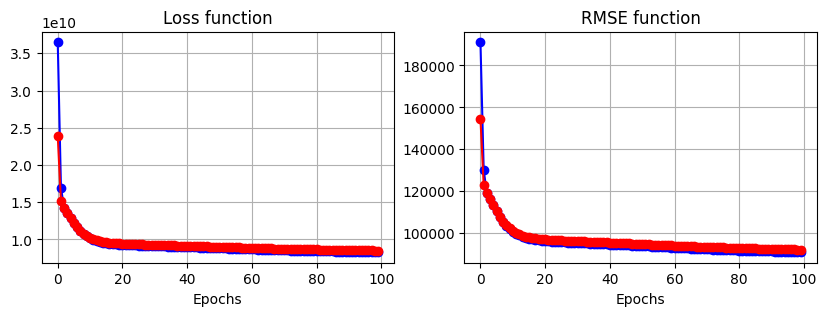

In [ ]:
# Visualizing the evolution of the training
evolution = wd_history_2.history

fig, (ax1, ax2) = plt.subplots(ncols= 2, figsize= (10, 3))
ax1.plot(history.epoch, evolution["loss"], "-ob", label="Training loss")
ax1.plot(history.epoch, evolution["val_loss"], "-or", label="Validation loss")
ax1.set_xlabel("Epochs")
ax1.set_title("Loss function")
ax1.grid()

ax2.plot(history.epoch, evolution["root_mean_squared_error"], "-ob", label="Training RMSE")
ax2.plot(history.epoch, evolution["val_root_mean_squared_error"], "-or", label="Validation RMSE")
ax2.set_xlabel("Epochs")
ax2.set_title("RMSE function")
ax2.grid()

plt.show()

This model turns out to be the worst performer so far—both training and validation metrics diverge further from the results I obtained in previous iterations despite covering the same number of epochs. The arbitrary feature split likely hurts performance: by restricting the deep path to only four features, I am limiting the model's capacity to learn complex cross-feature interactions that involve features from both groups. Meanwhile, the wide path lacks the representational power to compensate.

This reinforces an important lesson: architectural complexity does not automatically translate into better performance. Without a principled feature-routing strategy, the additional structural overhead can actually degrade results.

### Wide & Deep with regularisation via auxiliary output

In this final iteration, I keep the split-feature structure from the previous variant but add an auxiliary output branching off the last hidden layer of the deep path. The idea is that by requiring the deep path to produce its own independent prediction—weighted at 10% of the total loss—I constrain its learned representations to remain meaningful on their own. This acts as an implicit regularisation mechanism: the deep layers cannot become overly specialised to the combined signal and must retain general predictive power, which can reduce overfitting risk.

In [ ]:
# Same split-feature structure, now with an auxiliary output for deep-path regularisation
tf.random.set_seed(15) #For guaranteeing reproducibility
normalize1 = tf.keras.layers.Normalization()
normalize2 = tf.keras.layers.Normalization()
concatenate = tf.keras.layers.Concatenate()

# Deep path
input1__ = tf.keras.layers.Input(shape=[4,])
normalized1 = normalize1(input1__)
hidden_1 = tf.keras.layers.Dense(100, activation="relu")(normalized1)
hidden_2 = tf.keras.layers.Dense(50, activation="relu")(hidden_1)
hidden_3 = tf.keras.layers.Dense(10, activation="relu")(hidden_2)

# Wide path
input2__ = tf.keras.layers.Input(shape=[4,])
normalized2 = normalize2(input2__)

# Auxiliary output — forces the deep path to maintain standalone predictive quality
supp_output__ = tf.keras.layers.Dense(1)(hidden_3)

# Primary output — combines both paths
concatenation = concatenate([hidden_3, normalized2])
output__ = tf.keras.layers.Dense(1)(concatenation)

w_d_model_3 = tf.keras.Model(inputs = [input1__, input2__], outputs = [output__, supp_output__])
w_d_model_3.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_10    │ (None, 4)         │          9 │ input_layer_16[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 100)       │        500 │ normalization_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 50)        │      5,050 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 10)        │        510 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_11    │ (None, 4)         │          9 │ input_layer_17[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 14)        │          0 │ dense_41[0][0],   │
│ (Concatenate)       │                   │            │ normalization_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 1)         │         15 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 1)         │         11 │ dense_41[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,104 (23.85 KB)

 Trainable params: 6,086 (23.77 KB)

 Non-trainable params: 18 (80.00 B)

In [ ]:
# Weighted loss: 90% on the primary output, 10% on the auxiliary (regularisation signal)
w_d_model_3.compile(loss=["mean_squared_error", "mean_squared_error"], loss_weights=[0.9, 0.1],
                    optimizer="adam", metrics=["root_mean_squared_error", "root_mean_squared_error"])

normalize1.adapt(x_tra_deep)
normalize2.adapt(x_tra_wide)

checkpoints_log = tf.keras.callbacks.ModelCheckpoint(filepath="wd2_checkpoints.weights.h5",
                                                     save_weights_only=True)
early_stopping_wd3 = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# Both outputs receive the same target—the auxiliary just constrains the deep path
wd_history_3 = w_d_model_3.fit([x_tra_deep, x_tra_wide], [y_tra, y_tra], epochs=100,
                               validation_data=([x_val_deep, x_val_wide], [y_val, y_val]),
                               callbacks=[checkpoints_log, early_stopping_wd3])

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_42_loss: 54821928960.0000 - dense_42_root_mean_squared_error: 234136.2031 - dense_43_loss: 54676750336.0000 - dense_43_root_mean_squared_error: 233826.4375 - loss: 54689292288.0000 - val_dense_42_loss: 51748937728.0000 - val_dense_42_root_mean_squared_error: 225809.0312 - val_dense_43_loss: 51134595072.0000 - val_dense_43_root_mean_squared_error: 224452.9688 - val_loss: 50440192000.0000
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_42_loss: 33184473088.0000 - dense_42_root_mean_squared_error: 182181.1719 - dense_43_loss: 32059854848.0000 - dense_43_root_mean_squared_error: 179068.2500 - loss: 32177885184.0000 - val_dense_42_loss: 18638307328.0000 - val_dense_42_root_mean_squared_error: 134988.5000 - val_dense_43_loss: 17828907008.0000 - val_dense_43_root_mean_squared_error: 132044.8438 - val_loss: 17514446848.0000
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_42_loss: 14991017984.0000 - dense_42_

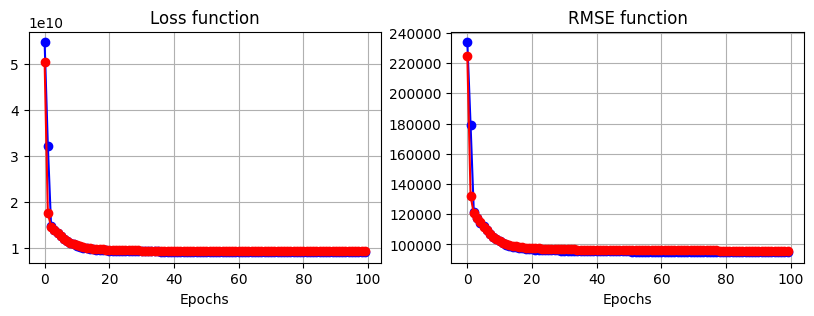

In [ ]:
# Visualizing the evolution of the training
evolution = wd_history_3.history

fig, (ax1, ax2) = plt.subplots(ncols= 2, figsize= (10, 3))
ax1.plot(history.epoch, evolution["loss"], "-ob", label="Training loss")
ax1.plot(history.epoch, evolution["val_loss"], "-or", label="Validation loss")
ax1.set_xlabel("Epochs")
ax1.set_title("Loss function")
ax1.grid()

ax2.plot(history.epoch, evolution["dense_43_root_mean_squared_error"], "-ob", label="Training RMSE")
ax2.plot(history.epoch, evolution["val_dense_43_root_mean_squared_error"], "-or", label="Validation RMSE")
ax2.set_xlabel("Epochs")
ax2.set_title("RMSE function")
ax2.grid()

plt.show()

As expected, the auxiliary output does not produce a major performance leap—the regularisation introduces a mild trade-off by slightly constraining the deep path's expressiveness. Nonetheless, this variant successfully demonstrates the mechanism: the auxiliary loss forces the hidden layers to maintain individually meaningful representations, which in more complex or overfit-prone settings would help keep the model generalisable.

**Summary of findings across all architectures:**

| Architecture | Key observation |
|---|---|
| MLP (unscaled) | Demonstrates that skipping standardization leads to poor and unstable convergence |
| MLP (scaled, Sequential) | ~25% RMSE improvement with standardization; exposes the external preprocessing burden |
| MLP (Functional API) | Equivalent performance, but self-contained model with embedded normalization |
| Wide & Deep (full) | No improvement over MLP—wide path adds noise rather than signal for this dataset |
| Wide & Deep (split features) | Worst performer—arbitrary feature routing degrades cross-feature learning |
| Wide & Deep (auxiliary output) | Mild regularisation effect; demonstrates multi-output training pattern |

The overarching takeaway from this notebook is that **architectural choices must be motivated by the data and problem structure**, not applied generically. For this particular dataset—moderate size, all continuous features, no sparsity—the simple MLP with integrated normalization proved most effective. The Wide & Deep architecture, while theoretically appealing, did not find a use case here. Where this exploration adds the most value is in establishing the Keras patterns (Functional API, callbacks, multi-input/output models) that I will carry forward into more complex problems where these architectural options become genuinely impactful.